In [1]:
import jpype
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import random
import string
from typing import List, Tuple

# Запуск JVM
jpype.startJVM(classpath=[".."])

# Импорт Java-классов
HuffmanCoding = jpype.JClass("utils.huffman.HuffmanCoding")

In [2]:
def generate_random_text(length: int, unique_chars: int = 26) -> str:
    """Генерация случайного текста с заданным количеством уникальных символов"""
    # Выбираем подмножество символов
    chars = random.sample(string.ascii_letters + string.digits + string.punctuation, unique_chars)
    # Генерируем текст с разной частотой символов
    weights = [random.randint(1, 10) for _ in range(unique_chars)]
    total_weight = sum(weights)
    probabilities = [w/total_weight for w in weights]
    return ''.join(np.random.choice(chars, size=length, p=probabilities))

def test_example():
    # Тестовый пример
    text = "this is an example of huffman coding"
    
    print("\nТестовый пример:")
    print(f"Исходный текст: {text}")
    
    # Кодирование
    huffman = HuffmanCoding()
    encoding_result = huffman.encode(text)
    
    # Вывод таблицы кодов
    print("\nТаблица кодов:")
    code_table = sorted(encoding_result.codeTable.items(), key=lambda x: len(x[1]))
    for char, code in code_table:
        print(f"'{char}': {code}")
    
    print(f"\nЗакодированный текст: {encoding_result.encodedText}")
    print(f"Размер исходного текста: {encoding_result.originalSize} бит")
    print(f"Размер сжатого текста: {encoding_result.compressedSize} бит")
    print(f"Степень сжатия: {encoding_result.originalSize / encoding_result.compressedSize:.2f}x")
    print(f"Время кодирования: {encoding_result.encodingTime} нс")
    
    # Декодирование
    decoding_result = huffman.decode(encoding_result.encodedText, encoding_result.codeTable)
    print(f"\nДекодированный текст: {decoding_result.decodedText}")
    print(f"Время декодирования: {decoding_result.decodingTime} нс")
    
    # Проверка корректности
    assert text == decoding_result.decodedText, "Ошибка: декодированный текст не совпадает с исходным!"

def analyze_performance():
    # Анализ производительности для разных размеров входных данных
    lengths = [100, 500, 1000, 5000, 10000]
    encoding_times = []
    decoding_times = []
    compression_ratios = []
    
    print("\nАнализ производительности:")
    
    for length in lengths:
        print(f"\nТестирование для длины текста: {length}")
        
        # Генерируем случайный текст
        text = generate_random_text(length)
        
        # Кодирование
        huffman = HuffmanCoding()
        encoding_result = huffman.encode(text)
        encoding_times.append(encoding_result.encodingTime)
        
        # Декодирование
        decoding_result = huffman.decode(encoding_result.encodedText, encoding_result.codeTable)
        decoding_times.append(decoding_result.decodingTime)
        
        # Степень сжатия
        compression_ratio = encoding_result.originalSize / encoding_result.compressedSize
        compression_ratios.append(compression_ratio)
        
        # Проверка корректности
        assert text == decoding_result.decodedText
    
    # Построение графиков
    plt.figure(figsize=(15, 5))
    
    # График времени выполнения
    plt.subplot(1, 2, 1)
    plt.plot(lengths, encoding_times, 'o-', label='Кодирование')
    plt.plot(lengths, decoding_times, 'o-', label='Декодирование')
    plt.xlabel('Длина текста')
    plt.ylabel('Время выполнения (нс)')
    plt.title('Время выполнения алгоритма')
    plt.legend()
    plt.grid(True)
    
    # График степени сжатия
    plt.subplot(1, 2, 2)
    plt.plot(lengths, compression_ratios, 'o-')
    plt.xlabel('Длина текста')
    plt.ylabel('Степень сжатия')
    plt.title('Эффективность сжатия')
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()
    
    # Вывод результатов в таблицу
    results = pd.DataFrame({
        'length': lengths,
        'encoding_time': encoding_times,
        'decoding_time': decoding_times,
        'compression_ratio': compression_ratios
    })
    print("\nРезультаты тестирования:")
    print(results.to_string(index=False))

def analyze_character_distribution():
    # Анализ влияния распределения символов на степень сжатия
    length = 1000
    unique_chars_range = [2, 4, 8, 16, 32, 64]
    compression_ratios = []
    
    print("\nАнализ влияния распределения символов:")
    
    for unique_chars in unique_chars_range:
        print(f"\nКоличество уникальных символов: {unique_chars}")
        
        # Генерируем текст с заданным количеством уникальных символов
        text = generate_random_text(length, unique_chars)
        
        # Кодирование
        huffman = HuffmanCoding()
        encoding_result = huffman.encode(text)
        
        # Степень сжатия
        compression_ratio = encoding_result.originalSize / encoding_result.compressedSize
        compression_ratios.append(compression_ratio)
    
    # Построение графика
    plt.figure(figsize=(8, 5))
    plt.plot(unique_chars_range, compression_ratios, 'o-')
    plt.xlabel('Количество уникальных символов')
    plt.ylabel('Степень сжатия')
    plt.title('Зависимость степени сжатия от разнообразия символов')
    plt.grid(True)
    plt.show()
    
    # Вывод результатов в таблицу
    results = pd.DataFrame({
        'unique_chars': unique_chars_range,
        'compression_ratio': compression_ratios
    })
    print("\nРезультаты анализа распределения символов:")
    print(results.to_string(index=False))

def main():
    # Тестирование на примере
    test_example()
    
    # Анализ производительности
    analyze_performance()
    
    # Анализ влияния распределения символов
    analyze_character_distribution()


Тестовый пример:
Исходный текст: this is an example of huffman coding

Таблица кодов:
' ': 111
'n': 000
'a': 1100
'e': 0100
'f': 1011
'h': 0011
'i': 1101
'm': 0101
'o': 0111
's': 1010
'c': 00100
'd': 00101
'g': 10010
'l': 01101
'p': 10011
't': 10000
'u': 10001
'x': 01100

Закодированный текст: 10000001111011010111110110101111100000111010001100110001011001101101010011101111011111001110001101110110101110000011100100011100101110100010010
Размер исходного текста: 288 бит
Размер сжатого текста: 143 бит
Степень сжатия: 2.01x
Время кодирования: 1336300 нс

Декодированный текст: this is an example of huffman coding
Время декодирования: 62900 нс

Анализ производительности:

Тестирование для длины текста: 100

Тестирование для длины текста: 500

Тестирование для длины текста: 1000

Тестирование для длины текста: 5000

Тестирование для длины текста: 10000


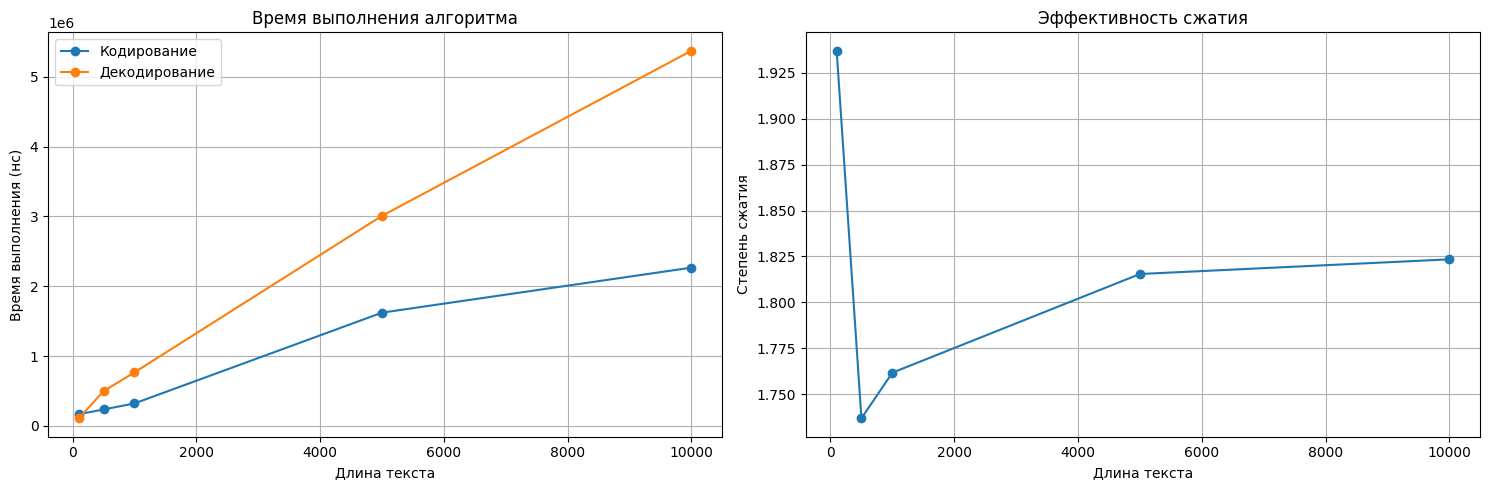


Результаты тестирования:
 length  encoding_time  decoding_time  compression_ratio
    100         167600         108300           1.937046
    500         235300         497700           1.736865
   1000         322100         766800           1.761726
   5000        1621700        3008500           1.815459
  10000        2266300        5372300           1.823445

Анализ влияния распределения символов:

Количество уникальных символов: 2

Количество уникальных символов: 4

Количество уникальных символов: 8

Количество уникальных символов: 16

Количество уникальных символов: 32

Количество уникальных символов: 64


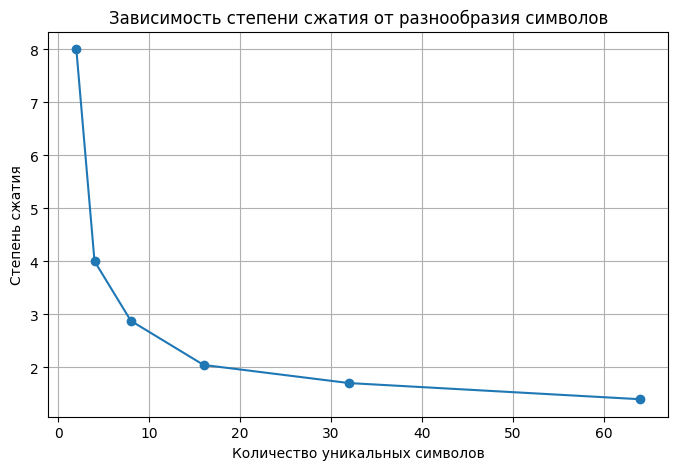


Результаты анализа распределения символов:
 unique_chars  compression_ratio
            2           8.000000
            4           4.000000
            8           2.875629
           16           2.043423
           32           1.701404
           64           1.396648


In [3]:
main()